# AML Project 2

## 1. Feature Selection 

In the first part we will implement multiple feature selection methods and combine them using voting to identify the most important features for cost-effective customer targeting.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')


### 1.1 Loading Data

In [4]:
# Set random seed for reproducibility
np.random.seed(42)

x_train = np.loadtxt('../data/x_train.txt', skiprows=1)
y_train = np.loadtxt('../data/y_train.txt', skiprows=1)
x_test = np.loadtxt('../data/x_test.txt', skiprows=1)

print(f"Training set shape: {x_train.shape}")
print(f"Test set shape: {x_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Class distribution: {np.bincount(y_train.astype(int))}")

# Create feature names
n_features = x_train.shape[1]
feature_names = np.array([f'Feature_{i}' for i in range(n_features)])
print(f"\nNumber of features: {n_features}")

Training set shape: (5000, 500)
Test set shape: (5000, 500)
Training labels shape: (5000,)
Class distribution: [2512 2488]

Number of features: 500


### 1.2 Multicollinearity Analysis

Before feature selection, let's analyze feature correlations.


In [5]:
# Compute full correlation matrix
correlation_matrix = np.corrcoef(x_train.T)

high_corr_pairs = []
for i in range(correlation_matrix.shape[0]):
    for j in range(i+1, correlation_matrix.shape[1]):
        corr_value = correlation_matrix[i, j]
        if abs(corr_value) > 0.9:  # High correlation threshold  # LATER TRY 0.8 and 0.75
            high_corr_pairs.append((i, j, corr_value))

# Sort by correlation strength
high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

print(f"Total features: {n_features}")
print(f"High correlation pairs (|corr| > 0.9): {len(high_corr_pairs)}")

# Create dataframe for high correlation pairs
corr_df = pd.DataFrame([
    {
        'Rank': idx,
        'Feature 1': feature_names[i],
        'Feature 2': feature_names[j],
        'Correlation': corr
    }
    for idx, (i, j, corr) in enumerate(high_corr_pairs[:20], 1)
])

display(corr_df.reset_index(drop=True))

Total features: 500
High correlation pairs (|corr| > 0.9): 8


,Rank,Feature 1,Feature 2,Correlation
0,1,Feature_31,Feature_174,1.000000
1,2,Feature_159,Feature_415,1.000000
2,3,Feature_31,Feature_175,0.915218
3,4,Feature_174,Feature_175,0.915218
4,5,Feature_190,Feature_344,0.912228
5,6,Feature_175,Feature_264,0.912131
6,7,Feature_308,Feature_328,0.912005
7,8,Feature_198,Feature_254,0.910321


In [6]:
# Define features to remove
features_to_remove = [
    'Feature_174',  # correlated with Feature_264
    'Feature_175',  # correlated with Feature_264
    'Feature_31',   # correlated with Feature_264
    'Feature_344',  # correlated with Feature_190
    'Feature_328',  # correlated with Feature_308
    'Feature_415',  # correlated with Feature_159
    'Feature_198',  # correlated with Feature_254
]

# Get original feature names before filtering
original_feature_names = np.array([f'Feature_{i}' for i in range(x_train.shape[1])])

# Create mask for features to keep
final_feature_mask = np.array([f not in features_to_remove for f in original_feature_names])

# Filter data and feature names
x_train = x_train[:, final_feature_mask]
x_test = x_test[:, final_feature_mask]
feature_names = original_feature_names[final_feature_mask]

# UPDATE: Recalculate n_features after removing correlated features
n_features = x_train.shape[1]

print(f"Original number of features: 500")
print(f"Number of correlated features removed: {len(features_to_remove)}")
print(f"Number of features left after removing correlated ones: {n_features}")

Original number of features: 500
Number of correlated features removed: 7
Number of features left after removing correlated ones: 493


**TODO** Add Zero-Variance threshold analysis

**TODO** ADD quasi-id, timestamp filtering

### 1.3 Feature Selection Methods

We'll implement multiple methods and combine them:
1. **Random Forest Importance**: Tree-based feature importance
2. **Gradient Boosting Importance**: Boosting-based feature importance  
3. **Permutation Importance**: Model-agnostic importance based on permutation
4. **Mutual Information**: Information-theoretic measure of dependence
5. **F-Score**: ANOVA F-statistic for feature selection
6. **Logistic Regression (LASSO) Coefficients**: Linear model coefficients magnitude


#### 1.3.1 Random Forest

In [7]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(x_train, y_train)
rf_importance = rf_model.feature_importances_

In [8]:
print(f"Random Forest model trained. Accuracy on training data: {rf_model.score(x_train, y_train):.4f}")

# Normalize to 0-1 range
rf_importance_normalized = rf_importance / rf_importance.max()

print(f"Top 10 features by Random Forest:")
top_10_rf = np.argsort(rf_importance)[-10:][::-1]
for rank, idx in enumerate(top_10_rf, 1):
    print(f"{rank}. {feature_names[idx]}: {rf_importance[idx]:.6f}")

Random Forest model trained. Accuracy on training data: 1.0000
Top 10 features by Random Forest:
1. Feature_190: 0.011788
2. Feature_254: 0.011017
3. Feature_159: 0.010052
4. Feature_214: 0.009296
5. Feature_379: 0.007881
6. Feature_389: 0.007548
7. Feature_264: 0.007524
8. Feature_223: 0.006870
9. Feature_482: 0.006771
10. Feature_341: 0.006355


#### 1.3.2 Gradient Boosting

In [9]:
gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb_model.fit(x_train, y_train)
gb_importance = gb_model.feature_importances_

In [10]:
print(f"Gradient Boosting model trained. Accuracy on training data: {gb_model.score(x_train, y_train):.4f}")

# Normalize to 0-1 range
gb_importance_normalized = gb_importance / gb_importance.max()

print(f"Top 10 features by Gradient Boosting:")
top_10_gb = np.argsort(gb_importance)[-10:][::-1]
for rank, idx in enumerate(top_10_gb, 1):
    print(f"{rank}. {feature_names[idx]}: {gb_importance[idx]:.6f}")

Gradient Boosting model trained. Accuracy on training data: 0.9630
Top 10 features by Gradient Boosting:
1. Feature_190: 0.039314
2. Feature_214: 0.037803
3. Feature_254: 0.037329
4. Feature_379: 0.036038
5. Feature_159: 0.033956
6. Feature_264: 0.030716
7. Feature_341: 0.028519
8. Feature_116: 0.021701
9. Feature_389: 0.019939
10. Feature_482: 0.018515


#### 1.3.3 Permutation Importance

In [11]:
from sklearn.model_selection import train_test_split

x_tr, x_val, y_tr, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(x_tr, y_tr)  
rf_importance = rf_model.feature_importances_

perm_importance = permutation_importance(rf_model, x_val, y_val, n_repeats=10, random_state=42, n_jobs=-1)
perm_importance_values = perm_importance.importances_mean

In [12]:
print(f"Permutation Importance calculated on Random Forest model")

# Normalize to 0-1 range
perm_importance_normalized = perm_importance_values / (perm_importance_values.max() + 1e-8)

print(f"Top 10 features by Permutation Importance:")
top_10_perm = np.argsort(perm_importance_values)[-10:][::-1]
for rank, idx in enumerate(top_10_perm, 1):
    print(f"{rank}. {feature_names[idx]}: {perm_importance_values[idx]:.6f}")

Permutation Importance calculated on Random Forest model
Top 10 features by Permutation Importance:
1. Feature_264: 0.012900
2. Feature_190: 0.011200
3. Feature_254: 0.011000
4. Feature_116: 0.009300
5. Feature_341: 0.008500
6. Feature_379: 0.007900
7. Feature_159: 0.007100
8. Feature_214: 0.006700
9. Feature_434: 0.006700
10. Feature_160: 0.006400


#### 1.3.4 Mutual Information 

In [13]:
mi_scores = mutual_info_classif(x_train, y_train, random_state=42)

print(f"Mutual Information scores calculated")

# Normalize to 0-1 range
mi_scores_normalized = mi_scores / (mi_scores.max() + 1e-8)

print(f"Top 10 features by Mutual Information:")
top_10_mi = np.argsort(mi_scores)[-10:][::-1]
for rank, idx in enumerate(top_10_mi, 1):
    print(f"{rank}. {feature_names[idx]}: {mi_scores[idx]:.6f}")

Mutual Information scores calculated
Top 10 features by Mutual Information:
1. Feature_10: 0.029785
2. Feature_456: 0.021367
3. Feature_470: 0.020561
4. Feature_312: 0.018987
5. Feature_159: 0.018163
6. Feature_254: 0.017258
7. Feature_4: 0.017163
8. Feature_379: 0.017061
9. Feature_190: 0.016577
10. Feature_151: 0.016375


#### 1.3.5 F-Score

In [14]:
f_scores, _ = f_classif(x_train, y_train)

print(f"F-scores calculated")

# Normalize to 0-1 range
f_scores_normalized = f_scores / (f_scores.max() + 1e-8)

print(f"Top 10 features by F-Score:")
top_10_f = np.argsort(f_scores)[-10:][::-1]
for rank, idx in enumerate(top_10_f, 1):
    print(f"{rank}. {feature_names[idx]}: {f_scores[idx]:.6f}")

F-scores calculated
Top 10 features by F-Score:
1. Feature_389: 65.771559
2. Feature_223: 60.237727
3. Feature_160: 56.468392
4. Feature_10: 51.510035
5. Feature_308: 43.722840
6. Feature_264: 37.632162
7. Feature_254: 35.993215
8. Feature_190: 33.817880
9. Feature_59: 33.531665
10. Feature_312: 30.115437


#### 1.3.6 Lasso Logistic Regression

In [15]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)

# Train logistic regression with L1 regularization (LASSO)
lr_model = LogisticRegression(penalty='l1', solver='saga', C=0.1, max_iter=1000, random_state=42, n_jobs=-1)
lr_model.fit(x_train_scaled, y_train)

# Get absolute coefficients
lr_importance = np.abs(lr_model.coef_[0])

print(f"Logistic Regression model trained. Accuracy on training data: {lr_model.score(x_train_scaled, y_train):.4f}")

# Normalize to 0-1 range
lr_importance_normalized = lr_importance / (lr_importance.max() + 1e-8)

print(f"Top 10 features by Logistic Regression Coefficients: ")
top_10_lr = np.argsort(lr_importance)[-10:][::-1]
for rank, idx in enumerate(top_10_lr, 1):
    print(f"{rank}. {feature_names[idx]}: {lr_importance[idx]:.6f}")

Logistic Regression model trained. Accuracy on training data: 0.6616
Top 10 features by Logistic Regression Coefficients: 
1. Feature_389: 0.235048
2. Feature_308: 0.180108
3. Feature_254: 0.171687
4. Feature_264: 0.170685
5. Feature_190: 0.155959
6. Feature_463: 0.079855
7. Feature_468: 0.077572
8. Feature_228: 0.071592
9. Feature_69: 0.070075
10. Feature_365: 0.066058


### 1.4 Voting Ensemble - Combined Feature Importance

Now we combine all 6 methods using a voting scheme to create a robust ranking of features.

The final output will be a leaderboard of the top 20 features based on their median rank across all methods, which we will use for model training in the next part.


In [16]:
rankings = np.zeros((n_features, 6))

# Method 1: Random Forest
rankings[:, 0] = n_features - np.argsort(np.argsort(rf_importance))

# Method 2: Gradient Boosting
rankings[:, 1] = n_features - np.argsort(np.argsort(gb_importance))

# Method 3: Permutation Importance
rankings[:, 2] = n_features - np.argsort(np.argsort(perm_importance_values))

# Method 4: Mutual Information
rankings[:, 3] = n_features - np.argsort(np.argsort(mi_scores))

# Method 5: F-Score
rankings[:, 4] = n_features - np.argsort(np.argsort(f_scores))

# Method 6: Logistic Regression
rankings[:, 5] = n_features - np.argsort(np.argsort(lr_importance))

# Calculate median rank for each feature (using median for voting ensemble - more robust to outliers)
average_rank = np.median(rankings, axis=1)

# Sort by median rank (lower is better)
final_ranking = np.argsort(average_rank)

In [17]:
print("Top 20 features based on average rank across all methods:")

# Create leaderboard dataframe
leaderboard_data = []

for rank, feature_idx in enumerate(final_ranking[:20], 1):
    leaderboard_data.append({
        'Rank': rank,
        'Feature': feature_names[feature_idx],
        'Avg Rank': f"{average_rank[feature_idx]:.2f}",
        'RF': f"{rankings[feature_idx, 0]:.0f}",
        'GB': f"{rankings[feature_idx, 1]:.0f}",
        'Perm': f"{rankings[feature_idx, 2]:.0f}",
        'MI': f"{rankings[feature_idx, 3]:.0f}",
        'F-Score': f"{rankings[feature_idx, 4]:.0f}",
        'LR': f"{rankings[feature_idx, 5]:.0f}",
    })

leaderboard_df = pd.DataFrame(leaderboard_data)
display(leaderboard_df)

# Store top 20 features
top_20_features = final_ranking[:20]
top_20_feature_names = feature_names[top_20_features]



Top 20 features based on average rank across all methods:


,Rank,Feature,Avg Rank,RF,GB,Perm,MI,F-Score,LR
0,1,Feature_254,3.00,3,3,3,6,7,3
1,2,Feature_190,3.50,2,1,2,9,8,5
2,3,Feature_264,6.00,6,6,1,14,6,4
3,4,Feature_159,6.00,1,5,7,5,153,224
4,5,Feature_389,7.00,5,9,81,73,1,1
5,6,Feature_379,8.50,9,4,6,8,258,236
6,7,Feature_341,13.00,7,7,5,19,194,256
7,8,Feature_10,14.00,14,14,395,1,4,490
8,9,Feature_308,15.00,17,13,17,62,5,2
9,10,Feature_463,23.00,33,15,483,30,16,6


### 1.5 Visualizations


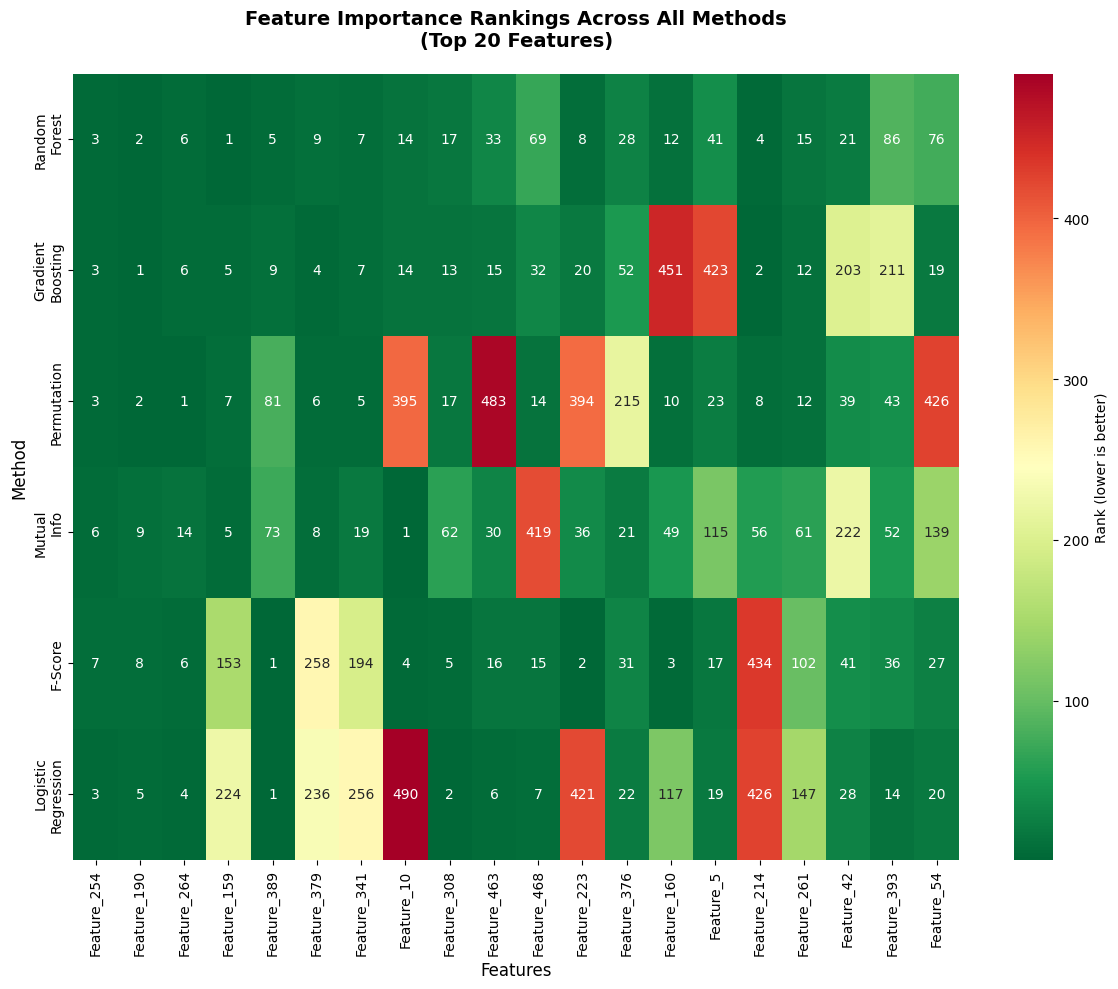

In [19]:
fig, ax = plt.subplots(figsize=(12, 10))

top_20_rankings = rankings[top_20_features]

method_names = ['Random\nForest', 'Gradient\nBoosting', 'Permutation', 
                'Mutual\nInfo', 'F-Score', 'Logistic\nRegression']
sns.heatmap(top_20_rankings.T, annot=True, fmt='.0f', cmap='RdYlGn_r', 
            xticklabels=top_20_feature_names, yticklabels=method_names,
            cbar_kws={'label': 'Rank (lower is better)'}, ax=ax)

ax.set_title('Feature Importance Rankings Across All Methods\n(Top 20 Features)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Features', fontsize=12)
ax.set_ylabel('Method', fontsize=12)

plt.tight_layout()
# plt.savefig('plots/feature_rankings_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


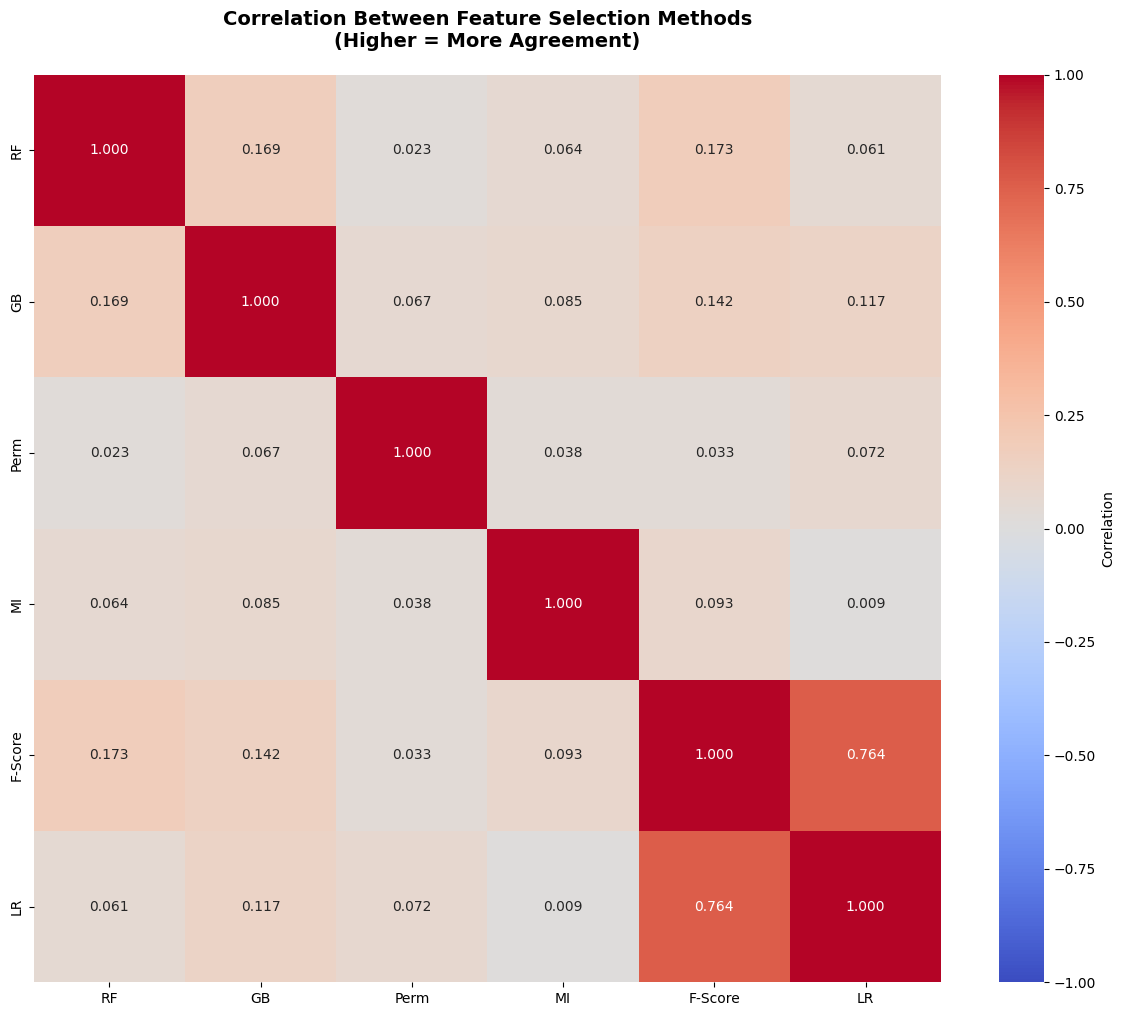

In [20]:
method_corr = np.corrcoef(rankings.T)

fig, ax = plt.subplots(figsize=(12, 10))

method_names_short = ['RF', 'GB', 'Perm', 'MI', 'F-Score', 'LR']
sns.heatmap(method_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            xticklabels=method_names_short, yticklabels=method_names_short,
            square=True, cbar_kws={'label': 'Correlation'}, ax=ax, vmin=-1, vmax=1)

ax.set_title('Correlation Between Feature Selection Methods\n(Higher = More Agreement)', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
# plt.savefig('plots/method_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

### 1.6 Multicollinearity Analysis for top features

In [21]:
x_train_selected = x_train[:, top_20_features]
x_test_selected = x_test[:, top_20_features]

corr_matrix_top20 = np.corrcoef(x_train_selected.T)

high_corr_top20 = []
for i in range(len(top_20_feature_names)):
    for j in range(i+1, len(top_20_feature_names)):
        if abs(corr_matrix_top20[i, j]) > 0.90:
            high_corr_top20.append({
                'Feature_1': top_20_feature_names[i],
                'Feature_2': top_20_feature_names[j],
                'Correlation': corr_matrix_top20[i, j]
            })

high_corr_top20 = sorted(high_corr_top20, key=lambda x: abs(x['Correlation']), reverse=True)

print(f"Total feature pairs in top 20: {len(top_20_feature_names) * (len(top_20_feature_names)-1) // 2}")
print(f"Highly correlated pairs (|r| > 0.90): {len(high_corr_top20)}")

high_corr_df = pd.DataFrame([
    {
        'Rank': idx,
        'Feature 1': pair['Feature_1'],
        'Feature 2': pair['Feature_2'],
        'Correlation': f"{pair['Correlation']:.4f}"
    }
    for idx, pair in enumerate(high_corr_top20, 1)
])

display(high_corr_df)

Total feature pairs in top 20: 190
Highly correlated pairs (|r| > 0.90): 0


""


In [22]:
# Correlation statistics
corr_flat = corr_matrix_top20[np.triu_indices_from(corr_matrix_top20, k=1)]
print(f"Correlation statistics among top 20:")
print(f"- Mean |r|: {np.mean(np.abs(corr_flat)):.4f}")
print(f"- Median |r|: {np.median(np.abs(corr_flat)):.4f}")
print(f"- Max |r|: {np.max(np.abs(corr_flat)):.4f}")
print(f"- % pairs with |r| > 0.50: {100 * np.sum(np.abs(corr_flat) > 0.50) / len(corr_flat):.1f}%")


Correlation statistics among top 20:
- Mean |r|: 0.0519
- Median |r|: 0.0096
- Max |r|: 0.8808
- % pairs with |r| > 0.50: 1.6%


### 1.7 Saving Final Selected Features

In [26]:
np.save("xtrain.npy", x_train_selected)

In [25]:
original_indices = np.where(final_feature_mask)[0] 
original_top20_indices = original_indices[top_20_features]
np.save('s../elected_data/final_feature_indices.npy', original_top20_indices)

np.save('../selected_data/x_train_final.npy', x_train_selected)
np.save('../selected_data/x_test_final.npy', x_test_selected)


print(f"Final filtered data exported:")
print(f"- x_train_final.npy: shape {x_train_selected.shape}")
print(f"- x_test_final.npy: shape {x_test_selected.shape}")

# Save results to CSV
results_df = leaderboard_df.copy()
results_df.to_csv('selected_data/feature_selection_leaderboard.csv', index=False)

FileNotFoundError: [Errno 2] No such file or directory: 's../elected_data/final_feature_indices.npy'

### 1.8 Summary

**Data Ready for Modeling:**
- `x_train_final.npy` (5000 × 20 features) - Training data
- `x_test_final.npy` (5000 × 20 features) - Test data  
- `final_feature_indices.npy` (20 indices) - Selected indices


**Current Status:**
- Removed correlated features to reduce multicollinearity
- Feature selection used **ensemble voting** (6 combined methods)
- Features ranked by their median place in each method ranking, not direct ROI optimization
- Final 20-feature set is a **recommended baseline**

**Next steps:**

1. Use the project's financial scoring formula to evaluate feature subsets: 
   ```
   Profit = (TP × 10) - (FP × 5) - (Features × 200)
   ```

2. **Test feature subsets iteratively** using k-fold cross-validation:
   - Start with top-ranked features
   - Add features one-by-one
   - Stop when marginal gain < feature cost (EUR 200)




In [ ]:
indices = np.load('selected_data/final_feature_indices.npy')
indices

array([254, 190, 264, 389, 159,  10, 341, 308, 379, 463, 468, 223, 376,
       214,   5, 261, 236,   4, 212,  54])